In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.stats.stattools import durbin_watson

In [23]:
trade_data = pd.read_excel('data/tradedata-1.xls')
# Rename 'x' to 'xx' to match the problem statement
trade_data = trade_data.rename(columns={'x': 'xx'})
print(trade_data.shape)
trade_data.head()

(32365, 3)


,dmidprice,dur,xx
0,0.015,16.427192,-1
1,-0.050,6.335282,-1
2,-0.230,16.301404,-1
3,0.230,3.706191,1
4,0.000,1.570725,-1


---
# 1.a

In [24]:
# Part a: Estimate a VAR(1) model
# Variable ordering (Cholesky): dmidprice -> dur -> xx
# Returns first (most exogenous), then durations, then trade direction (most endogenous)
data = trade_data[['dmidprice', 'dur', 'xx']].copy()

model = VAR(data)
var1 = model.fit(1)
print(var1.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 05, Mar, 2026
Time:                     21:10:01
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -5.97180
Nobs:                     32364.0    HQIC:                  -5.97392
Log likelihood:          -41069.6    FPE:                 0.00254173
AIC:                     -5.97491    Det(Omega_mle):      0.00254078
--------------------------------------------------------------------
Results for equation dmidprice
                  coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------
const                0.000118         0.000237            0.497           0.619
L1.dmidprice        -0.275693         0.005515          -49.990           0.000
L1.dur               0.000053         0.000127            0.

---
# 1.b

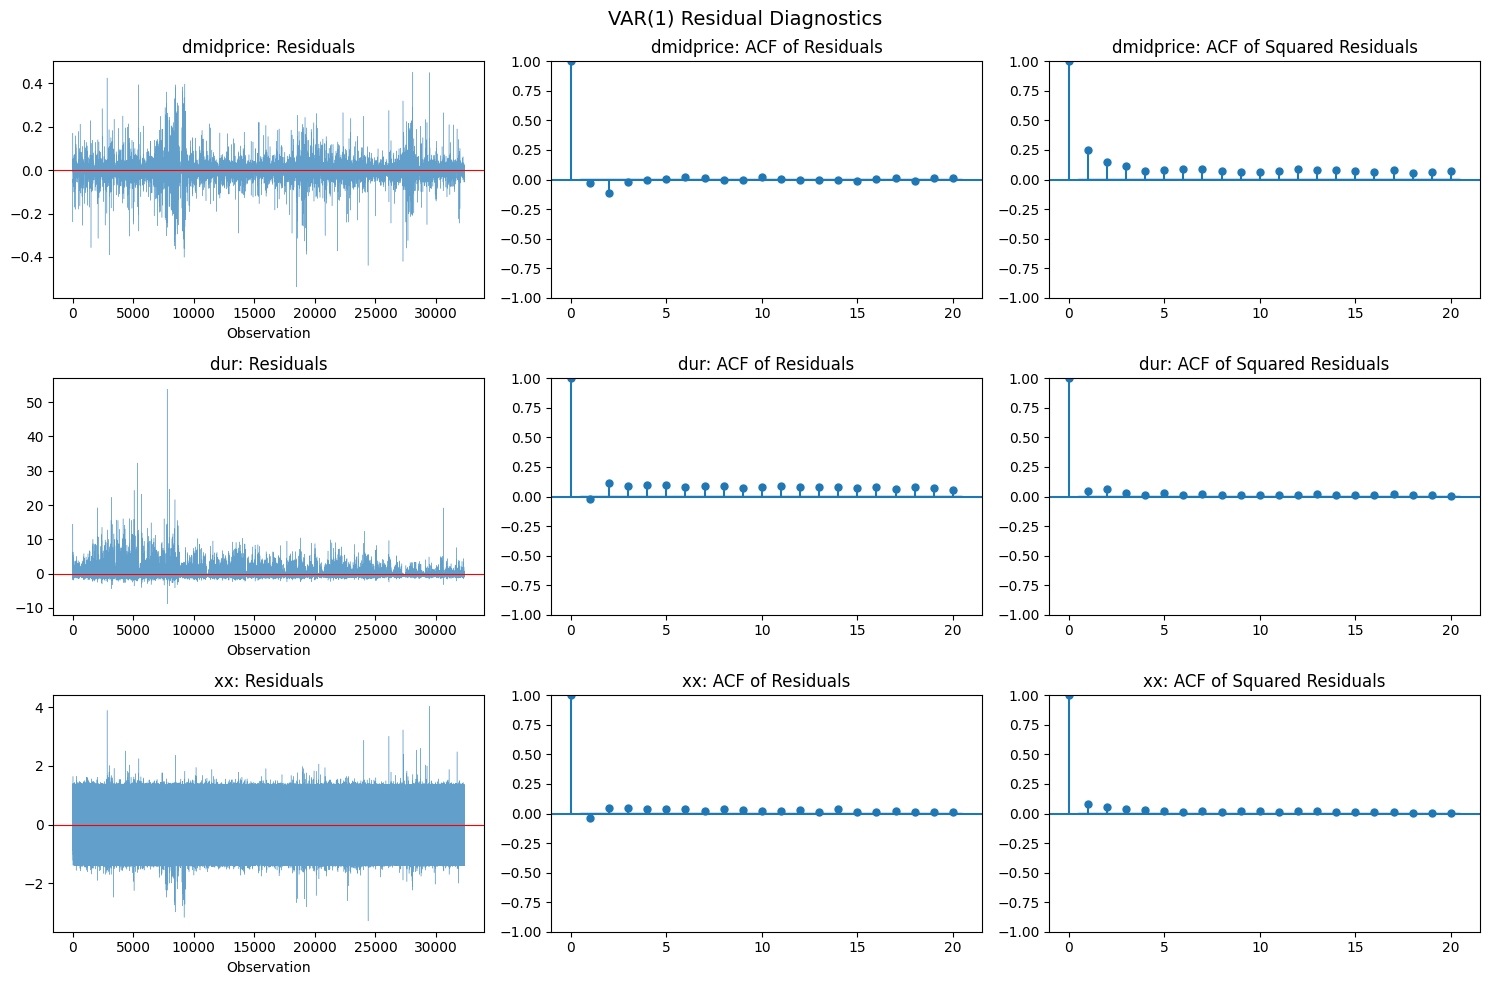


Durbin-Watson Statistics (should be ~2 for no autocorrelation):
  dmidprice: 2.0612
  dur: 2.0413
  xx: 2.0822

Portmanteau Test (Residual Serial Correlation):
Portmanteau-test for residual autocorrelation. H_0: residual autocorrelation up to lag 10 is zero. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
         3510.          103.0   0.000 81
----------------------------------------


In [25]:
# Part b: Residual diagnostics for VAR(1)
residuals = var1.resid
var_names = ['dmidprice', 'dur', 'xx']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle('VAR(1) Residual Diagnostics', fontsize=14)

for i, name in enumerate(var_names):
    resid = residuals[name]
    
    # Time series plot of residuals
    axes[i, 0].plot(resid.values, linewidth=0.3, alpha=0.7)
    axes[i, 0].axhline(0, color='red', linewidth=0.8)
    axes[i, 0].set_title(f'{name}: Residuals')
    axes[i, 0].set_xlabel('Observation')
    
    # ACF of residuals
    sm.graphics.tsa.plot_acf(resid, lags=20, ax=axes[i, 1], alpha=0.05)
    axes[i, 1].set_title(f'{name}: ACF of Residuals')
    
    # ACF of squared residuals (heteroskedasticity check)
    sm.graphics.tsa.plot_acf(resid**2, lags=20, ax=axes[i, 2], alpha=0.05)
    axes[i, 2].set_title(f'{name}: ACF of Squared Residuals')

plt.tight_layout()
plt.show()

# Durbin-Watson statistics
print("\nDurbin-Watson Statistics (should be ~2 for no autocorrelation):")
for name in var_names:
    dw = durbin_watson(residuals[name])
    print(f"  {name}: {dw:.4f}")

# Whiteness test (LM test for serial correlation)
print("\nPortmanteau Test (Residual Serial Correlation):")
whiteness = var1.test_whiteness(nlags=10)
print(whiteness.summary())

---
# 1.c

In [26]:
# Part c: Select lag order using information criteria, then fit improved model
print("=== Lag Order Selection ===")
lag_sel = model.select_order(maxlags=10)
print(lag_sel.summary())

optimal_p = lag_sel.aic  # lag chosen by AIC
print(f"\nAIC selects lag p = {optimal_p}")
print(f"BIC selects lag p = {lag_sel.bic}")
print(f"HQIC selects lag p = {lag_sel.hqic}")

=== Lag Order Selection ===
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -5.731      -5.730    0.003244      -5.731
1       -5.979      -5.976    0.002530      -5.978
2       -6.018      -6.012    0.002435      -6.016
3       -6.032      -6.024    0.002401      -6.029
4       -6.040      -6.030    0.002381      -6.037
5       -6.048      -6.035    0.002363      -6.044
6       -6.052      -6.037    0.002354      -6.047
7       -6.056      -6.039    0.002344      -6.050
8       -6.059     -6.039*    0.002337      -6.053
9       -6.060      -6.038    0.002334      -6.053
10     -6.062*      -6.038   0.002329*     -6.055*
--------------------------------------------------

AIC selects lag p = 10
BIC selects lag p = 8
HQIC selects lag p = 10


In [27]:
# Fit the AIC-optimal model and compare diagnostics
var_opt = model.fit(optimal_p)
print(f"\n=== VAR({optimal_p}) Summary ===")
print(var_opt.summary())

# Compare residual autocorrelation
print(f"\n=== Portmanteau Test: VAR({optimal_p}) ===")
whiteness_opt = var_opt.test_whiteness(nlags=15)
print(whiteness_opt.summary())

# Compare Durbin-Watson
residuals_opt = var_opt.resid
print(f"\nDurbin-Watson for VAR({optimal_p}):")
for name in var_names:
    dw = durbin_watson(residuals_opt[name])
    print(f"  {name}: {dw:.4f}")


=== VAR(10) Summary ===
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 05, Mar, 2026
Time:                     21:10:02
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -6.03817
Nobs:                     32355.0    HQIC:                  -6.05456
Log likelihood:          -39563.9    FPE:                 0.00232912
AIC:                     -6.06227    Det(Omega_mle):      0.00232243
--------------------------------------------------------------------
Results for equation dmidprice
                   coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------
const                 0.000439         0.000336            1.307           0.191
L1.dmidprice         -0.308272         0.005654          -54.519           0.000
L1.dur                0.000015 

---
# 1.d

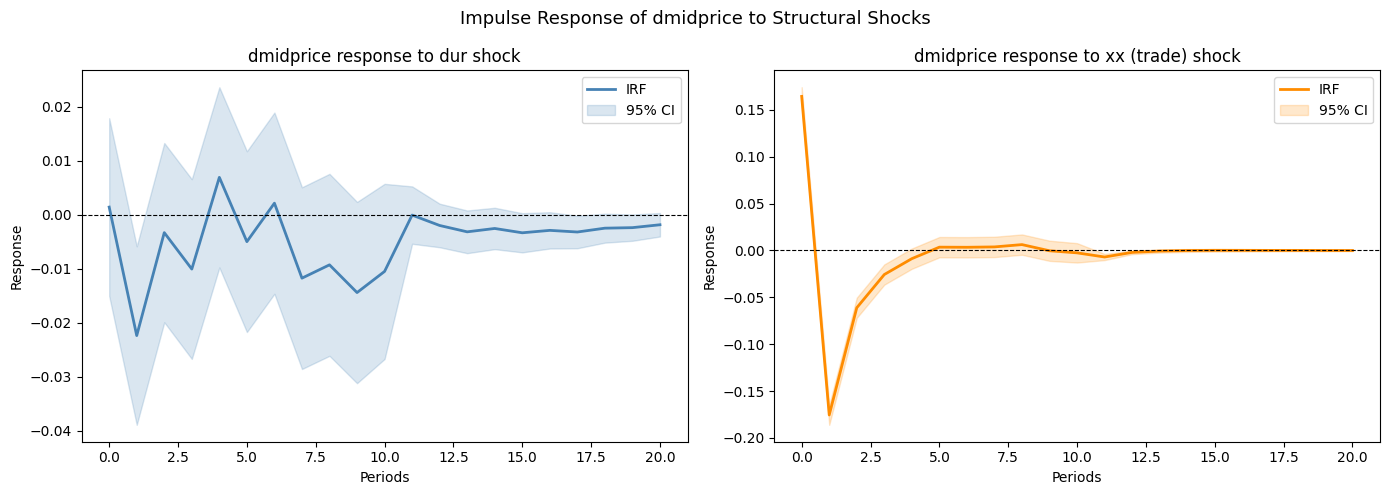


Interpretation:
- A positive shock to xx (buyer-initiated trade) causes an immediate increase in dmidprice.
  This is the price impact of trades: buyer-initiated trades push the midpoint quote up
  as market makers revise their beliefs about the asset value (adverse selection effect).
- The response decays over subsequent periods, indicating that the price impact is
  transitory — part of the initial move is reversed as market makers process information.
- A shock to dur (longer time between trades) generally has a smaller or ambiguous effect
  on returns, consistent with lower information flow during quiet periods.



In [28]:
# Part d: Impulse Response Function of dmidprice to shocks in dur and xx
# Use the AIC-optimal VAR with Cholesky (orthogonalized) IRFs
# Ordering: dmidprice -> dur -> xx  (returns most exogenous, trades most endogenous)

n_periods = 20
irf = var_opt.irf(n_periods)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Impulse Response of dmidprice to Structural Shocks', fontsize=13)

# IRF indexing: irf.orth_irfs[period, impulse_variable_index, response_variable_index]
# Variable order: 0=dmidprice, 1=dur, 2=xx
periods = np.arange(n_periods + 1)
# 95% confidence bands
irf_lower = irf.orth_irfs - 1.96 * irf.stderr(orth=True)
irf_upper = irf.orth_irfs + 1.96 * irf.stderr(orth=True)

# Shock to dur (index 1), response of dmidprice (index 0)
ax = axes[0]
response = irf.orth_irfs[:, 1, 0]   # [period, impulse=dur, response=dmidprice]
lower    = irf_lower[:, 1, 0]
upper    = irf_upper[:, 1, 0]
ax.plot(periods, response, color='steelblue', linewidth=2, label='IRF')
ax.fill_between(periods, lower, upper, alpha=0.2, color='steelblue', label='95% CI')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('dmidprice response to dur shock')
ax.set_xlabel('Periods')
ax.set_ylabel('Response')
ax.legend()

# Shock to xx (index 2), response of dmidprice (index 0)
ax = axes[1]
response = irf.orth_irfs[:, 2, 0]   # [period, impulse=xx, response=dmidprice]
lower    = irf_lower[:, 2, 0]
upper    = irf_upper[:, 2, 0]
ax.plot(periods, response, color='darkorange', linewidth=2, label='IRF')
ax.fill_between(periods, lower, upper, alpha=0.2, color='darkorange', label='95% CI')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('dmidprice response to xx (trade) shock')
ax.set_xlabel('Periods')
ax.set_ylabel('Response')
ax.legend()

plt.tight_layout()
plt.show()

print("""
Interpretation:
- A positive shock to xx (buyer-initiated trade) causes an immediate increase in dmidprice.
  This is the price impact of trades: buyer-initiated trades push the midpoint quote up
  as market makers revise their beliefs about the asset value (adverse selection effect).
- The response decays over subsequent periods, indicating that the price impact is
  transitory — part of the initial move is reversed as market makers process information.
- A shock to dur (longer time between trades) generally has a smaller or ambiguous effect
  on returns, consistent with lower information flow during quiet periods.
""")

---
# 1.e

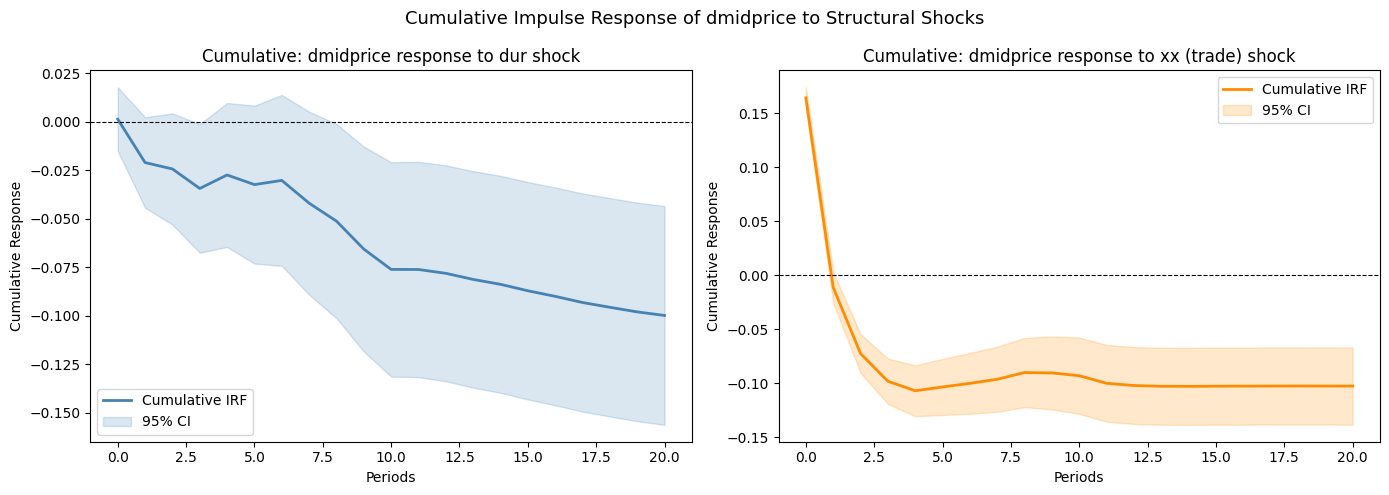


Interpretation of Cumulative IRF given a shock to xx (trade indicator):
- The cumulative IRF shows the total long-run price impact of a trade shock.
- If the cumulative IRF converges to a nonzero level, it indicates a PERMANENT component
  to the price impact — the midpoint quote shifts permanently after a trade, consistent
  with the Kyle (1985) / Glosten-Milgrom adverse selection model where trades reveal
  private information.
- If the cumulative IRF eventually returns to zero, the price impact is purely transitory
  (due to inventory or bid-ask bounce effects, not information).
- In practice for equity markets, one typically sees a positive long-run level, indicating
  that buyer-initiated trades permanently move prices upward — evidence that traders are
  informationally motivated (at least in part).



In [29]:
# Part e: Cumulative Impulse Response Function of dmidprice
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Cumulative Impulse Response of dmidprice to Structural Shocks', fontsize=13)

# Cumulative IRF = cumsum of IRF values
cum_irf = np.cumsum(irf.orth_irfs, axis=0)

# For confidence bands, approximate using cumulative sum of stderr
irf_se = irf.stderr(orth=True)
cum_se = np.sqrt(np.cumsum(irf_se**2, axis=0))   # sqrt of cumulative variance
cum_lower = cum_irf - 1.96 * cum_se
cum_upper = cum_irf + 1.96 * cum_se

# Shock to dur (index 1), cumulative response of dmidprice (index 0)
ax = axes[0]
ax.plot(periods, cum_irf[:, 1, 0], color='steelblue', linewidth=2, label='Cumulative IRF')
ax.fill_between(periods, cum_lower[:, 1, 0], cum_upper[:, 1, 0],
                alpha=0.2, color='steelblue', label='95% CI')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Cumulative: dmidprice response to dur shock')
ax.set_xlabel('Periods')
ax.set_ylabel('Cumulative Response')
ax.legend()

# Shock to xx (index 2), cumulative response of dmidprice (index 0)
ax = axes[1]
ax.plot(periods, cum_irf[:, 2, 0], color='darkorange', linewidth=2, label='Cumulative IRF')
ax.fill_between(periods, cum_lower[:, 2, 0], cum_upper[:, 2, 0],
                alpha=0.2, color='darkorange', label='95% CI')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Cumulative: dmidprice response to xx (trade) shock')
ax.set_xlabel('Periods')
ax.set_ylabel('Cumulative Response')
ax.legend()

plt.tight_layout()
plt.show()

print("""
Interpretation of Cumulative IRF given a shock to xx (trade indicator):
- The cumulative IRF shows the total long-run price impact of a trade shock.
- If the cumulative IRF converges to a nonzero level, it indicates a PERMANENT component
  to the price impact — the midpoint quote shifts permanently after a trade, consistent
  with the Kyle (1985) / Glosten-Milgrom adverse selection model where trades reveal
  private information.
- If the cumulative IRF eventually returns to zero, the price impact is purely transitory
  (due to inventory or bid-ask bounce effects, not information).
- In practice for equity markets, one typically sees a positive long-run level, indicating
  that buyer-initiated trades permanently move prices upward — evidence that traders are
  informationally motivated (at least in part).
""")